# 02. EDA — 타깃과 기상 데이터를 뜯어보기

**이 노트북이 하는 일 (Why)**
- EDA(Exploratory Data Analysis, 탐색적 데이터 분석)는 "그림을 예쁘게 그리는 것"이 아니라, **다음 단계(피처 엔지니어링·모델 선택)에서 내릴 결정의 근거를 모으는 것**이에요. 그래서 그래프 하나하나마다 "이걸 보고 무엇을 결정할지"를 마크다운에 먼저 적습니다.
- `eda-checklist` 스킬의 순서(타깃 → 기상 → 타깃×기상 관계 → SCADA → 시간 무결성)를 그대로 따릅니다.
- `01_preprocessing.ipynb`가 만든 parquet 캐시를 불러와서 씁니다 (원본 CSV를 다시 읽지 않아 빠릅니다). SCADA 원본만 이 노트북에서 새로 읽습니다.

**입력**: `data/processed/*.parquet` (01번 노트북 산출물), `data/train/scada_*.csv`, `data/info.xlsx`

**출력**: 이 노트북 자체는 새 캐시를 만들지 않습니다. 대신 `reports/02_eda.md`에 "무엇을 봤고, 그래서 무엇을 결정했는지"를 정리합니다.

**이 노트북에서 답을 찾을 01번 노트북의 미해결 질문**
1. 라벨 결측(group_1 104개/group_2 103개/group_3 8766개)이 특정 시기에 몰려 있는가?
2. test LDAPS의 결측 752개는 어느 시각에서 발생했는가 (발표분 전체 누락인가, 격자 일부만인가)?

## 0. 셋업
패키지를 불러오고, 01번 노트북에서 만든 parquet 캐시를 불러옵니다. `src/metric.py`에 있는 `TARGET_COLS`, `CAPACITY_KWH`를 그대로 가져다 써서, 이 노트북에도 같은 상수를 또 적어두는 실수를 방지합니다 (값이 어긋나면 채점 로직과 EDA 해석이 서로 달라지는 문제가 생기므로).

**한글 폰트 설정도 여기서 합니다**: matplotlib 기본 폰트는 한글을 지원하지 않아서, 그래프의 한글 제목·축 이름이 네모(□)로 깨져 보입니다. Windows에는 "맑은 고딕"(Malgun Gothic) 폰트가 기본으로 깔려 있으므로 이 폰트를 지정합니다. 마이너스(음수) 부호도 이 폰트에서 깨지는 경우가 있어 `axes.unicode_minus`를 꺼둡니다.

In [44]:
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

SEED = 42
np.random.seed(SEED)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "data").exists(), "REPO_ROOT를 찾지 못했습니다. 노트북 실행 위치를 확인하세요."
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.metric import TARGET_COLS, CAPACITY_KWH

DATA_DIR = REPO_ROOT / "data"
TRAIN_DIR = DATA_DIR / "train"
PROCESSED_DIR = DATA_DIR / "processed"

TRAIN_START = pd.Timestamp("2022-01-01 01:00:00")
TRAIN_END = pd.Timestamp("2024-01-01 00:00:00")
VALID_START = pd.Timestamp("2024-01-01 01:00:00")
VALID_END = pd.Timestamp("2025-01-01 00:00:00")

print("python executable:", sys.executable)
print("REPO_ROOT:", REPO_ROOT)
print("TARGET_COLS:", TARGET_COLS)
print("CAPACITY_KWH:", CAPACITY_KWH)

python executable: c:\Users\cho03\Desktop\wind_forecast\venv\Scripts\python.exe
REPO_ROOT: c:\Users\cho03\Desktop\wind_forecast
TARGET_COLS: ['kpx_group_1', 'kpx_group_2', 'kpx_group_3']
CAPACITY_KWH: {'kpx_group_1': 21600, 'kpx_group_2': 21600, 'kpx_group_3': 21000}


In [45]:
train_base_wide = pd.read_parquet(PROCESSED_DIR / "train_base_wide.parquet")
train_base_agg = pd.read_parquet(PROCESSED_DIR / "train_base_agg.parquet")
test_base_wide = pd.read_parquet(PROCESSED_DIR / "test_base_wide.parquet")
gfs_grid_meta = pd.read_parquet(PROCESSED_DIR / "gfs_grid_meta.parquet")
ldaps_grid_meta = pd.read_parquet(PROCESSED_DIR / "ldaps_grid_meta.parquet")

print("train_base_wide:", train_base_wide.shape)
print("train_base_agg:", train_base_agg.shape)
print("test_base_wide:", test_base_wide.shape)

train_base_wide: (26304, 801)
train_base_agg: (26304, 136)
test_base_wide: (8760, 799)


## 1. 타깃(train_labels) 뜯어보기 — 최우선
모델이 맞혀야 하는 대상 자체를 가장 먼저, 가장 깊게 봅니다. 기상 데이터보다 타깃을 먼저 이해해야, 나중에 "이 피처가 타깃과 왜 관련 있는지"를 판단할 기준이 생깁니다.

In [46]:
labels_df = train_base_wide[["forecast_kst_dtm"] + TARGET_COLS].copy()
labels_df.head()

,forecast_kst_dtm,kpx_group_1,kpx_group_2,kpx_group_3
0,2022-01-01 01:00:00,12004.421,9719.242,NaN
1,2022-01-01 02:00:00,12901.137,10297.768,NaN
2,2022-01-01 03:00:00,12091.200,10731.663,NaN
3,2022-01-01 04:00:00,17167.768,13841.242,NaN
4,2022-01-01 05:00:00,19134.758,14014.800,NaN


### 1-1. 그룹별 라벨 제공 기간과 결측 시점
01번 노트북에서 결측 개수(group_1 104개, group_2 103개, group_3 8766개)를 이미 봤습니다. 여기서는 **그 결측이 언제 발생했는지(특정 기간에 몰려 있는지, 아니면 여기저기 흩어져 있는지)**를 확인합니다. 몰려 있다면 터빈 점검·고장 구간일 가능성이 높고, 흩어져 있다면 센서 오류 같은 다른 원인을 의심해야 해요.

In [47]:
for col in TARGET_COLS:
    s = labels_df.set_index("forecast_kst_dtm")[col]
    valid = s.dropna()
    print(f"{col}: 값이 있는 기간 {valid.index.min()} ~ {valid.index.max()}, 결측 {s.isna().sum()}개")

kpx_group_1: 값이 있는 기간 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00, 결측 104개
kpx_group_2: 값이 있는 기간 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00, 결측 103개
kpx_group_3: 값이 있는 기간 2023-01-01 01:00:00 ~ 2025-01-01 00:00:00, 결측 8766개


In [48]:
missing_by_month = (
    labels_df.set_index("forecast_kst_dtm")[TARGET_COLS]
    .isna()
    .resample("MS")
    .sum()
)
# 셋 중 하나라도 그 달에 결측이 있는 달만 보여준다
missing_by_month[missing_by_month.sum(axis=1) > 0]

,kpx_group_1,kpx_group_2,kpx_group_3
forecast_kst_dtm,,,
2022-01-01,0,0,743
2022-02-01,0,0,672
2022-03-01,2,2,744
2022-04-01,0,0,720
2022-05-01,0,0,744
2022-06-01,0,0,720
2022-07-01,11,11,744
2022-08-01,0,0,744
2022-09-01,0,0,720


### 1-2. 발전량 분포
히스토그램으로 분포 모양을 봅니다. 무풍 시간이 많으면 0 근처에 값이 몰리고(왼쪽 봉우리), 바람이 충분하면 설비용량 근처에서 정격 출력으로 막히는 두 번째 봉우리가 생길 것으로 예상합니다(파워커브의 "정격 구간"이 평평하기 때문).

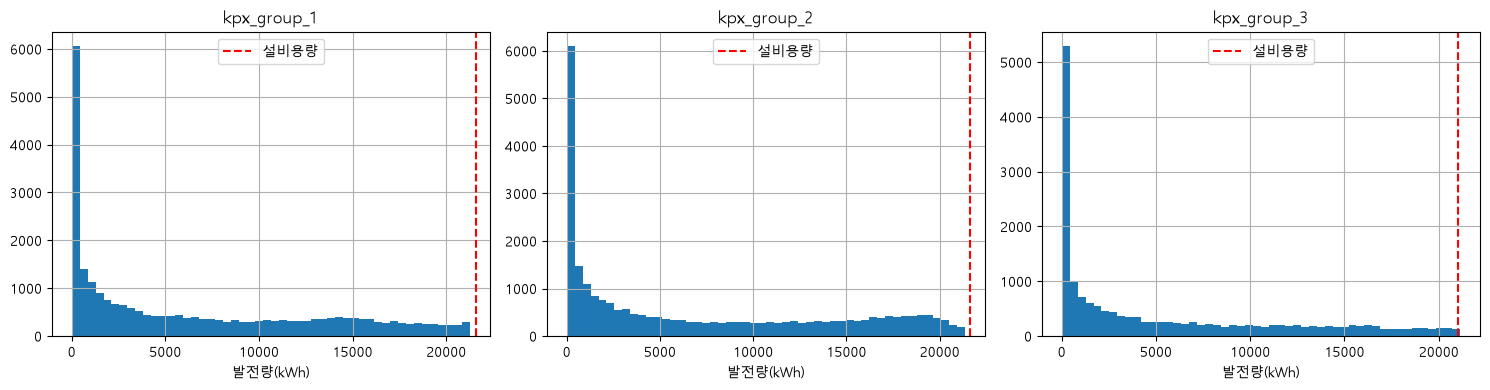

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, TARGET_COLS):
    labels_df[col].dropna().hist(bins=50, ax=ax)
    ax.axvline(CAPACITY_KWH[col], color="red", linestyle="--", label="설비용량")
    ax.set_title(col)
    ax.set_xlabel("발전량(kWh)")
    ax.legend()
plt.tight_layout()
plt.show()

### 1-3. 평가 대상 비율
채점 기준(`src/metric.py`)은 실제 발전량이 설비용량의 10% 이상인 시간만 채점합니다. 즉 나머지 시간(저발전)은 아무리 틀려도 점수에 영향이 없어요. 전체 중 몇 %가 실제로 채점 대상인지 확인해서, 모델이 어느 구간에 집중해야 하는지 감을 잡습니다.

In [50]:
for col in TARGET_COLS:
    s = labels_df[col].dropna()
    valid_ratio = (s >= CAPACITY_KWH[col] * 0.10).mean()
    print(f"{col}: 평가 대상(설비용량 10% 이상) 비율 = {valid_ratio:.1%} (결측 제외 {len(s)}개 중)")

kpx_group_1: 평가 대상(설비용량 10% 이상) 비율 = 60.7% (결측 제외 26200개 중)
kpx_group_2: 평가 대상(설비용량 10% 이상) 비율 = 60.7% (결측 제외 26201개 중)
kpx_group_3: 평가 대상(설비용량 10% 이상) 비율 = 53.7% (결측 제외 17538개 중)


### 1-4. 월별 평균 발전량 (계절 패턴)
겨울에 바람이 강한 지역인지, 여름에 강한 지역인지에 따라 피처 설계(계절성 반영)가 달라집니다.

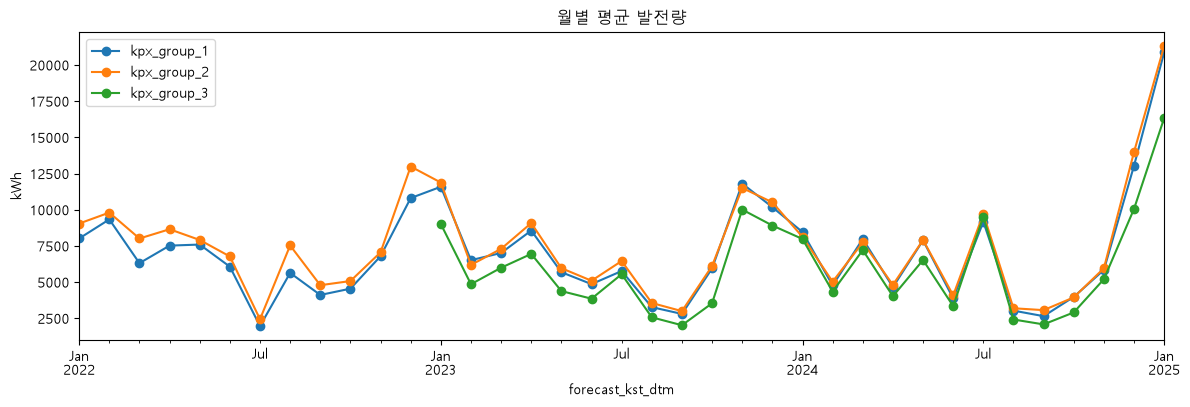

In [51]:
monthly_mean = (
    labels_df.set_index("forecast_kst_dtm")[TARGET_COLS]
    .resample("MS")
    .mean()
)
monthly_mean.plot(figsize=(14, 4), marker="o")
plt.title("월별 평균 발전량")
plt.ylabel("kWh")
plt.show()

### 1-5. 그룹 간 상관관계
같은 발전단지 안에 있으니 세 그룹의 발전량은 서로 높은 상관을 보일 것으로 예상합니다. 상관이 높다면 "한 그룹의 피처를 다른 그룹 예측에도 보조로 쓸 수 있다"는 근거가 됩니다.

In [52]:
labels_df[TARGET_COLS].corr()

,kpx_group_1,kpx_group_2,kpx_group_3
kpx_group_1,1.000000,0.955350,0.903694
kpx_group_2,0.955350,1.000000,0.928294
kpx_group_3,0.903694,0.928294,1.000000


### 1-6. 시간대별 평균 발전량 (일주기)
태백 가덕산은 산악 지형이라, 낮과 밤의 기온 차이로 생기는 산악풍(산곡풍) 때문에 발전량이 하루 주기로 오르내릴 수 있습니다.

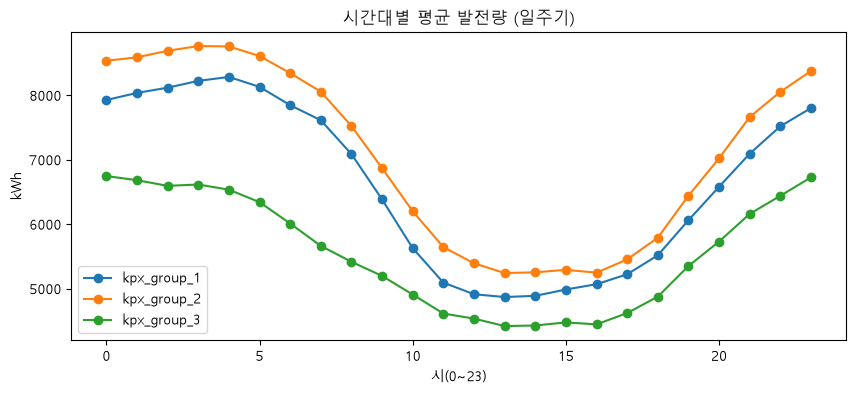

In [53]:
hourly_mean = (
    labels_df.assign(hour=labels_df["forecast_kst_dtm"].dt.hour)
    .groupby("hour")[TARGET_COLS]
    .mean()
)
hourly_mean.plot(figsize=(10, 4), marker="o")
plt.title("시간대별 평균 발전량 (일주기)")
plt.xlabel("시(0~23)")
plt.ylabel("kWh")
plt.show()

### 1-7. 연도별 분포 변화
연도가 지나며 평균·표준편차가 크게 바뀌면(터빈 증설, 노후화 등) 오래된 데이터에 같은 가중치를 줄지 다시 생각해야 합니다.

**주의**: `train_labels.csv`는 `2025-01-01 00:00:00` 딱 1시간만 2025년 자료로 걸쳐 있습니다. 그래서 연도별 평균에 표본 개수(count)를 같이 표시합니다 — count가 1인 연도(2025)의 평균은 "표본 1개짜리 착시"이지 실제 추세가 아니므로 해석에서 제외해야 합니다.

In [54]:
yearly_stats = (
    labels_df.assign(year=labels_df["forecast_kst_dtm"].dt.year)
    .groupby("year")[TARGET_COLS]
    .agg(["count", "mean", "std"])
)
yearly_stats

kpx_group_1                            kpx_group_2                            kpx_group_3                           
           count          mean          std       count          mean          std       count          mean          std
year                                                                                                                     
2022        8664   6561.329096  6231.116101        8664   7520.534942  7156.945791           0           NaN          NaN
2023        8757   7000.421112  6780.950655        8758   7226.109431  6972.181536        8759   5638.874657  6203.971429
2024        8778   6302.687647  6698.406278        8778   6488.365732  6831.798056        8778   5487.700727  6382.495069
2025           1  20870.337000          NaN           1  21304.232000          NaN           1  16328.905000          NaN

## 2. 기상 예보(GFS/LDAPS) 뜯어보기
타깃을 이해했으니, 이제 예측에 쓸 재료(기상 예보)를 봅니다. 먼저 격자가 실제로 어디에 있는지 지도로 확인하고, 결측·단위 문제를 점검합니다.

### 2-1. 격자 위치 지도 + 터빈 위치 겹쳐 보기
`info.xlsx`의 터빈 좌표(구글 좌표, "도°분'초"" 형식)를 십진수 위경도로 바꿔서, GFS/LDAPS 격자 위치와 함께 지도에 그립니다. 이렇게 하면 "이 터빈에는 어느 격자가 제일 가까운지"를 눈으로/계산으로 확인할 수 있어요.

`info.xlsx`의 `KPX그룹` 컬럼은 그룹마다 대표 터빈 한 줄에만 값이 적혀 있어서(나머지는 빈칸), 지난 세션에 확인한 규칙(제작사·호기 번호 기준: VESTAS 1~6호기=group_1, 7~12호기=group_2, UNISON 전체=group_3)으로 직접 매핑하고, 그룹설비용량으로 다시 한번 검증합니다.

**여기서 쓰는 `info.xlsx` 컬럼들이 무슨 뜻인지**: 발전량 공식 `P = ½ · ρ(공기밀도) · A(로터 면적) · Cp(출력계수) · v³(풍속)` 기준으로 보면 이해가 쉬워요.
- `hub_height_m` (허브 높이): 블레이드가 붙은 터빈 몸통(나셀)의 지상 높이(이 데이터는 117m). 바람은 땅에 가까울수록 마찰로 느려지고 높이 올라갈수록 빨라지므로(윈드시어), 예보의 10m 풍속보다 허브 높이에 가까운 100m 풍속이 터빈이 실제로 맞는 바람에 더 가깝습니다 — 그래서 2-5·3-1번 셀에서 GFS 100m를 대표 풍속으로 씁니다.
- `rotor_diameter_m` (로터 직경): 블레이드가 돌며 그리는 원의 지름(VESTAS 126m, UNISON 136m). 공식의 A(로터 면적, 원 넓이)를 결정하며, 로터가 클수록 같은 바람에서 더 많은 에너지를 걷어갑니다 — UNISON이 터빈 한 대당 용량이 더 큰(4.2MW>3.6MW) 이유이기도 합니다.
- `capacity_mw` (설비용량): 터빈 **한 대**의 최대 출력. VESTAS 3.6MW, UNISON 4.2MW.
- `group_capacity_mw` (그룹설비용량): **KPX 그룹 전체**(터빈 여러 대 합)의 설비용량. group_1 = 3.6MW×6대 = 21.6MW.

In [55]:
def dms_to_decimal(dms_str):
    '''DMS(도-분-초) 좌표 문자열을 (위도, 경도) 십진수로 바꾼다. 예: 37도16분55.61초N 128도57분02.10초E'''
    pattern = r"(\d+)°(\d+)'([\d.]+)\x22([NS])\s+(\d+)°(\d+)'([\d.]+)\x22([EW])"
    m = re.match(pattern, dms_str.strip())
    assert m is not None, f"좌표 형식을 못 읽었습니다: {dms_str}"
    lat_d, lat_m, lat_s, lat_dir, lon_d, lon_m, lon_s, lon_dir = m.groups()
    lat = float(lat_d) + float(lat_m) / 60 + float(lat_s) / 3600
    lon = float(lon_d) + float(lon_m) / 60 + float(lon_s) / 3600
    if lat_dir == "S":
        lat = -lat
    if lon_dir == "W":
        lon = -lon
    return lat, lon


info_raw = pd.read_excel(DATA_DIR / "info.xlsx", sheet_name="info", header=3)
info_raw = info_raw.dropna(axis=1, how="all")
assert len(info_raw.columns) == 11, f"예상과 다른 컬럼 수: {len(info_raw.columns)}"
info_raw.columns = [
    "단계", "명칭", "제작사", "모델명", "호기", "좌표", "KPX그룹",
    "hub_height_m", "rotor_diameter_m", "capacity_mw", "group_capacity_mw",
]
info_raw = info_raw.dropna(subset=["호기"]).reset_index(drop=True)

info_raw[["turbine_lat", "turbine_lon"]] = info_raw["좌표"].apply(
    lambda s: pd.Series(dms_to_decimal(s))
)

print("info_raw shape:", info_raw.shape)
info_raw[["단계", "제작사", "호기", "turbine_lat", "turbine_lon"]].head()

info_raw shape: (17, 13)


,단계,제작사,호기,turbine_lat,turbine_lon
0,1,VESTAS,1,37.282114,128.950583
1,1,VESTAS,2,37.284458,128.949542
2,1,VESTAS,3,37.286525,128.949719
3,1,VESTAS,4,37.289753,128.951022
4,1,VESTAS,5,37.291167,128.954328


In [56]:
def assign_kpx_group(row):
    if row["제작사"] == "VESTAS" and row["호기"] <= 6:
        return "kpx_group_1"
    if row["제작사"] == "VESTAS" and row["호기"] >= 7:
        return "kpx_group_2"
    if row["제작사"] == "UNISON":
        return "kpx_group_3"
    return None


info_raw["kpx_group"] = info_raw.apply(assign_kpx_group, axis=1)

group_check = info_raw.groupby("kpx_group").agg(
    turbine_count=("호기", "count"), total_capacity_mw=("capacity_mw", "sum")
)
print(group_check)

assert group_check.loc["kpx_group_1", "turbine_count"] == 6
assert group_check.loc["kpx_group_2", "turbine_count"] == 6
assert group_check.loc["kpx_group_3", "turbine_count"] == 5
assert abs(group_check.loc["kpx_group_1", "total_capacity_mw"] - 21.6) < 1e-6
assert abs(group_check.loc["kpx_group_2", "total_capacity_mw"] - 21.6) < 1e-6
assert abs(group_check.loc["kpx_group_3", "total_capacity_mw"] - 21.0) < 1e-6
print("그룹-터빈 매핑(터빈 수·설비용량) 검증 완료.")

             turbine_count  total_capacity_mw
kpx_group                                    
kpx_group_1              6               21.6
kpx_group_2              6               21.6
kpx_group_3              5               21.0
그룹-터빈 매핑(터빈 수·설비용량) 검증 완료.


한 그룹은 터빈이 여러 대(6/6/5대)라서 좌표가 제각각입니다. "이 그룹에는 어느 기상 격자가 제일 가까운가"를 판단하려면 그룹을 대표하는 좌표 하나가 필요해서, 그룹에 속한 터빈들의 위도·경도를 평균 내 "그룹의 중심 위치(centroid)"를 만듭니다. 이 평균 좌표가 바로 다음 셀에서 최근접 격자를 찾는 기준점이 되고, 그렇게 찾은 격자의 풍속이 3절(타깃×기상 관계)에서 계속 "그룹 대표 풍속"으로 쓰입니다.

In [57]:
group_turbine_coords = info_raw.groupby("kpx_group")[["turbine_lat", "turbine_lon"]].mean()
group_turbine_coords

,turbine_lat,turbine_lon
kpx_group,,
kpx_group_1,37.287127,128.952021
kpx_group_2,37.282255,128.965148
kpx_group_3,37.275199,128.971444


각 그룹의 평균 좌표와 가장 가까운 GFS/LDAPS 격자를 찾습니다. 이 지역은 좁은 범위(수 km)라서 위경도 차이의 유클리드 거리만으로도 최근접 격자를 충분히 구별할 수 있습니다 (지구 곡률 보정 없이도 순위가 바뀌지 않을 만큼 좁은 범위).

In [58]:
def nearest_grid(lat, lon, grid_meta):
    dist = np.sqrt((grid_meta["latitude"] - lat) ** 2 + (grid_meta["longitude"] - lon) ** 2)
    return int(grid_meta.loc[dist.idxmin(), "grid_id"])


GROUP_NEAREST_GRID = {}
for group, row in group_turbine_coords.iterrows():
    GROUP_NEAREST_GRID[group] = {
        "gfs": nearest_grid(row["turbine_lat"], row["turbine_lon"], gfs_grid_meta),
        "ldaps": nearest_grid(row["turbine_lat"], row["turbine_lon"], ldaps_grid_meta),
    }

GROUP_NEAREST_GRID

{'kpx_group_1': {'gfs': 5, 'ldaps': 5},
 'kpx_group_2': {'gfs': 5, 'ldaps': 6},
 'kpx_group_3': {'gfs': 5, 'ldaps': 12}}

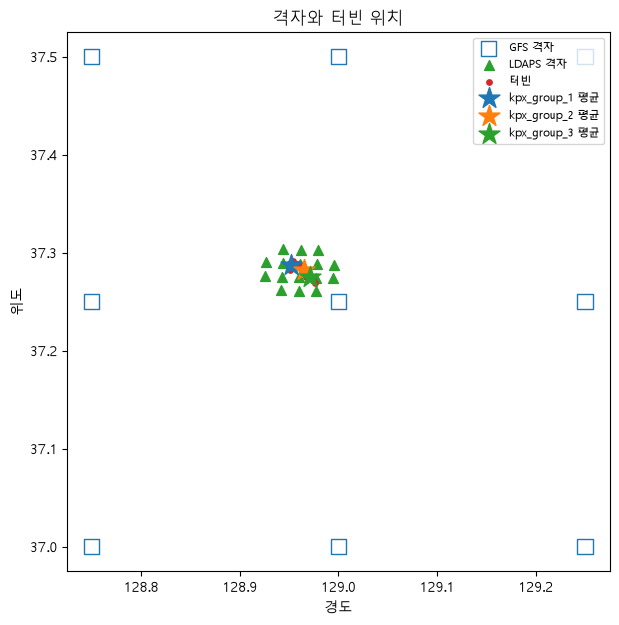

In [59]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(gfs_grid_meta["longitude"], gfs_grid_meta["latitude"],
           marker="s", s=120, facecolors="none", edgecolors="tab:blue", label="GFS 격자")
ax.scatter(ldaps_grid_meta["longitude"], ldaps_grid_meta["latitude"],
           marker="^", s=50, color="tab:green", label="LDAPS 격자")
ax.scatter(info_raw["turbine_lon"], info_raw["turbine_lat"],
           marker="o", s=15, color="tab:red", label="터빈")
for group, row in group_turbine_coords.iterrows():
    ax.scatter(row["turbine_lon"], row["turbine_lat"], marker="*", s=250, label=f"{group} 평균")

ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.set_title("격자와 터빈 위치")
ax.legend(fontsize=8, loc="best")
plt.show()

**주의: "그룹 평균 좌표 → 최근접 격자 1개"는 근사(approximation)입니다.** 한 그룹 안에서도 터빈마다 실제 최근접 격자가 다를 수 있어요. 격자 간격이 넓은 GFS(~25km)에서는 발전단지 전체 폭(~3km)이 격자 한 칸보다 훨씬 작아 문제가 안 되지만, 격자가 촘촘한 LDAPS(~1.5km)에서는 발전단지 폭과 격자 크기가 비슷해서 그룹 안에서도 터빈마다 최근접 격자가 갈릴 수 있습니다. 터빈 한 대 한 대의 최근접 격자를 직접 계산해서, 그룹 평균으로 고른 격자가 실제로 다수를 대표하는지 확인합니다.

In [60]:
info_raw["gfs_nearest"] = info_raw.apply(
    lambda r: nearest_grid(r["turbine_lat"], r["turbine_lon"], gfs_grid_meta), axis=1
)
info_raw["ldaps_nearest"] = info_raw.apply(
    lambda r: nearest_grid(r["turbine_lat"], r["turbine_lon"], ldaps_grid_meta), axis=1
)

print("--- GFS: 그룹별 터빈 최근접 격자 분포 ---")
print(info_raw.groupby("kpx_group")["gfs_nearest"].value_counts())
print()
print("--- LDAPS: 그룹별 터빈 최근접 격자 분포 ---")
print(info_raw.groupby("kpx_group")["ldaps_nearest"].value_counts())
print()
print("(참고) 그룹 평균 좌표 기준 최근접 격자:", GROUP_NEAREST_GRID)

--- GFS: 그룹별 터빈 최근접 격자 분포 ---
kpx_group    gfs_nearest
kpx_group_1  5              6
kpx_group_2  5              6
kpx_group_3  5              5
Name: count, dtype: int64

--- LDAPS: 그룹별 터빈 최근접 격자 분포 ---
kpx_group    ldaps_nearest
kpx_group_1  5                4
             6                2
kpx_group_2  6                3
             11               3
kpx_group_3  12               4
             6                1
Name: count, dtype: int64

(참고) 그룹 평균 좌표 기준 최근접 격자: {'kpx_group_1': {'gfs': 5, 'ldaps': 5}, 'kpx_group_2': {'gfs': 5, 'ldaps': 6}, 'kpx_group_3': {'gfs': 5, 'ldaps': 12}}


이 결과를 보면 GFS는 예상대로 전 터빈이 격자 하나로 모입니다(그룹 평균 방식이 완벽하게 안전). 반면 LDAPS는 그룹 평균이 고른 격자가 다수를 대표하는 경우도 있지만(group_1, group_3), 거의 반반으로 갈리는 그룹(group_2)도 있습니다 — 이런 경우 "격자 하나만 고르는" 방식은 그 그룹 터빈의 절반이 실제로 보는 바람을 무시하는 셈이에요.

그래서 지금부터는 **격자를 하나만 고르지 않고, 그룹 안에서 각 격자가 최근접인 터빈이 몇 대인지 비율을 가중치로 써서 여러 격자를 섞어 쓰겠습니다.** 예를 들어 group_2는 격자6(터빈 3대)과 격자11(터빈 3대)을 절반씩 섞습니다. GFS는 모든 그룹이 격자 하나(가중치 100%)로만 나오니 결과가 바뀌지 않고, LDAPS만 실질적으로 더 정확해집니다.

In [61]:
def group_grid_weights(kpx_group, source):
    """그룹 안에서 이 격자가 최근접인 터빈의 비율을 가중치로 반환한다."""
    col = "gfs_nearest" if source == "gfs" else "ldaps_nearest"
    sub = info_raw.loc[info_raw["kpx_group"] == kpx_group, col]
    return sub.value_counts(normalize=True).to_dict()


GROUP_GRID_WEIGHTS = {
    group: {source: group_grid_weights(group, source) for source in ["gfs", "ldaps"]}
    for group in TARGET_COLS
}
GROUP_GRID_WEIGHTS

{'kpx_group_1': {'gfs': {5: 1.0},
  'ldaps': {5: 0.6666666666666666, 6: 0.3333333333333333}},
 'kpx_group_2': {'gfs': {5: 1.0}, 'ldaps': {6: 0.5, 11: 0.5}},
 'kpx_group_3': {'gfs': {5: 1.0}, 'ldaps': {12: 0.8, 6: 0.2}}}

### 2-2 / 2-4. 결측 확인: test LDAPS 752개는 언제, 얼마나 빠졌나
01번 노트북에서 `test_base_wide`에 752개 결측 셀을 발견했습니다. 여기서 "특정 시각(발표분) 전체가 통째로 빠졌는지", 아니면 "일부 격자·변수만 빠졌는지"를 구분합니다. 전자라면 `leakage-guard` 기준으로 직전 발표분을 그대로 쓸지(ffill) 결정해야 하는 상황이고, 후자라면 원인이 다를 수 있어요.

In [62]:
ldaps_avail_col = "ldaps_data_available_kst_dtm"
gfs_avail_col = "gfs_data_available_kst_dtm"

missing_ldaps_ts = test_base_wide.loc[test_base_wide[ldaps_avail_col].isna(), "forecast_kst_dtm"]
missing_gfs_ts = test_base_wide.loc[test_base_wide[gfs_avail_col].isna(), "forecast_kst_dtm"]

print("LDAPS 발표분(data_available)이 아예 없는 시각 수:", len(missing_ldaps_ts))
print(sorted(missing_ldaps_ts.dt.strftime("%Y-%m-%d %H:%M").unique().tolist()))
print("GFS 발표분이 아예 없는 시각 수:", len(missing_gfs_ts))
print(sorted(missing_gfs_ts.dt.strftime("%Y-%m-%d %H:%M").unique().tolist()))

LDAPS 발표분(data_available)이 아예 없는 시각 수: 0
[]
GFS 발표분이 아예 없는 시각 수: 0
[]


In [63]:
ldaps_value_cols = [c for c in test_base_wide.columns if c.startswith("ldaps_g")]
na_per_row = test_base_wide[ldaps_value_cols].isna().sum(axis=1)

print("LDAPS 결측이 있는 행 수:", (na_per_row > 0).sum())
print("행별 결측 컬럼 수 분포 (0 초과만):")
print(na_per_row[na_per_row > 0].value_counts().sort_index())

LDAPS 결측이 있는 행 수: 3
행별 결측 컬럼 수 분포 (0 초과만):
224    2
304    1
Name: count, dtype: int64


### 2-3. `data_available_kst_dtm` 규칙 검증
명세서에 따르면 매일 09:00 초기화 예보가 13:00부터 쓸 수 있고, 다음날 01:00 ~ 그다음날 00:00의 24시간을 담당합니다. 즉 `forecast_kst_dtm - data_available_kst_dtm`은 12시간(다음날 01:00 예보)부터 35시간(그다음날 00:00 예보)까지의 범위 안에서만 나와야 해요. 실제로 그런지 시간 차이의 분포를 확인합니다.

In [64]:
delta_hours = (
    (train_base_wide["forecast_kst_dtm"] - train_base_wide["gfs_data_available_kst_dtm"])
    .dt.total_seconds() / 3600
)
delta_hours.value_counts().sort_index()

12.0    1096
13.0    1096
14.0    1096
15.0    1096
16.0    1096
17.0    1096
18.0    1096
19.0    1096
20.0    1096
21.0    1096
22.0    1096
23.0    1096
24.0    1096
25.0    1096
26.0    1096
27.0    1096
28.0    1096
29.0    1096
30.0    1096
31.0    1096
32.0    1096
33.0    1096
34.0    1096
35.0    1096
Name: count, dtype: int64

### 2-5. 격자 평균 풍속 분포 비교 (높이별, NWP별)
GFS 10m/100m, LDAPS 10m 풍속을 격자 평균(agg 캐시)으로 계산해 분포를 비교합니다. 허브 높이(약 117m)에 가까운 GFS 100m가 10m보다 발전량과의 관계를 더 잘 반영할 것으로 예상합니다 (풍력 도메인 지식: 지상 마찰 때문에 10m 풍속은 허브 높이보다 낮고 변동이 큼).

In [65]:
def wind_speed(u, v):
    return np.sqrt(u ** 2 + v ** 2)


ws_gfs_10m = wind_speed(train_base_agg["gfs_mean_heightAboveGround_10_10u"], train_base_agg["gfs_mean_heightAboveGround_10_10v"])
ws_gfs_100m = wind_speed(train_base_agg["gfs_mean_heightAboveGround_100_100u"], train_base_agg["gfs_mean_heightAboveGround_100_100v"])
ws_ldaps_10m = wind_speed(train_base_agg["ldaps_mean_heightAboveGround_10_10u"], train_base_agg["ldaps_mean_heightAboveGround_10_10v"])

print("GFS 10m 풍속 요약:\n", ws_gfs_10m.describe())
print("GFS 100m 풍속 요약:\n", ws_gfs_100m.describe())
print("LDAPS 10m 풍속 요약:\n", ws_ldaps_10m.describe())

GFS 10m 풍속 요약:
 count    26304.000000
mean         2.224642
std          1.482890
min          0.008853
25%          1.237195
50%          1.927894
75%          2.744736
max         12.783053
dtype: float64
GFS 100m 풍속 요약:
 count    26304.000000
mean         3.455482
std          2.638867
min          0.013692
25%          1.688005
50%          2.765438
75%          4.320353
max         20.551691
dtype: float64
LDAPS 10m 풍속 요약:
 count    26304.000000
mean         4.766253
std          2.523169
min          0.033692
25%          2.893800
50%          4.278912
75%          6.240968
max         16.861589
dtype: float64


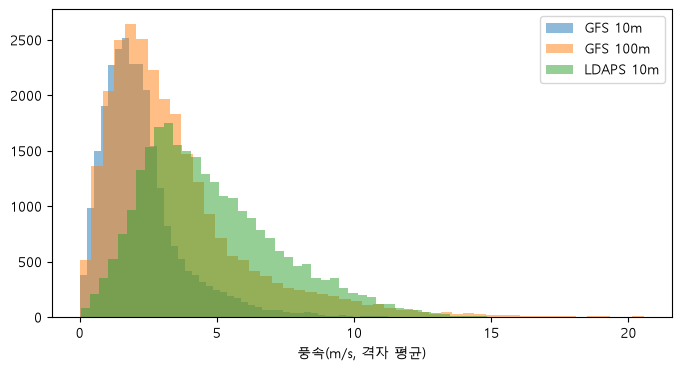

In [66]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ws_gfs_10m, bins=50, alpha=0.5, label="GFS 10m")
ax.hist(ws_gfs_100m, bins=50, alpha=0.5, label="GFS 100m")
ax.hist(ws_ldaps_10m, bins=50, alpha=0.5, label="LDAPS 10m")
ax.set_xlabel("풍속(m/s, 격자 평균)")
ax.legend()
plt.show()

### 2-6. 물리적 범위 재확인 (여러 컬럼)
01번 노트북에서는 격자 하나만 봤는데, 여기서는 격자 평균(agg) 기준으로 기온·습도·기압 범위를 조금 더 넓게 확인합니다.

In [67]:
check_cols = {
    "GFS 기온(격자평균, K)": "gfs_mean_heightAboveGround_2_2t",
    "LDAPS 기온(격자평균, K)": "ldaps_mean_heightAboveGround_2_t",
    "GFS 상대습도(격자평균, %)": "gfs_mean_heightAboveGround_2_2r",
    "LDAPS 상대습도(격자평균, %)": "ldaps_mean_heightAboveGround_2_r",
    "GFS 지표기압(격자평균, Pa)": "gfs_mean_surface_0_sp",
    "LDAPS 지표기압(격자평균, Pa)": "ldaps_mean_surface_0_sp",
}
for label, col in check_cols.items():
    print(f"{label}: {train_base_agg[col].min():.2f} ~ {train_base_agg[col].max():.2f}")

GFS 기온(격자평균, K): 254.35 ~ 305.19
LDAPS 기온(격자평균, K): 250.36 ~ 302.36
GFS 상대습도(격자평균, %): 15.73 ~ 99.66
LDAPS 상대습도(격자평균, %): 15.20 ~ 109.40
GFS 지표기압(격자평균, Pa): 93030.84 ~ 97135.32
LDAPS 지표기압(격자평균, Pa): 88054.03 ~ 92219.29


## 3. 타깃 × 기상 관계 — 피처 설계의 핵심 근거
여기서부터는 "어떤 기상 변수가 발전량과 실제로 관련 있는지"를 직접 확인합니다. 대표 풍속으로는 **각 그룹의 격자 가중치(`GROUP_GRID_WEIGHTS`, 2-1번에서 계산)로 섞은 GFS 100m 풍속**을 씁니다 — 터빈 허브 높이(약 117m)에 10m보다 가깝고, GFS만 80/100m 성분을 직접 제공하기 때문입니다(LDAPS는 10m와 50m 최대/최소만 제공). 다른 높이와의 비교는 3-3에서 따로 확인합니다.

In [68]:
def group_weighted_uv(df, group, source, u_var, v_var):
    """그룹에 속한 터빈들의 실제 최근접 격자 비율(GROUP_GRID_WEIGHTS)로 u/v 성분을 가중평균한다.
    풍향은 각도라서 평균 내기 전에 u/v(벡터 성분)를 먼저 섞어야 방향이 왜곡되지 않는다."""
    weights = GROUP_GRID_WEIGHTS[group][source]
    u_total, v_total = 0.0, 0.0
    for grid_id, weight in weights.items():
        u_total = u_total + df[f"{source}_g{grid_id}_{u_var}"] * weight
        v_total = v_total + df[f"{source}_g{grid_id}_{v_var}"] * weight
    return u_total, v_total


def wind_speed(u, v):
    return np.sqrt(u ** 2 + v ** 2)


def wind_direction(u, v):
    return (270 - np.degrees(np.arctan2(v, u))) % 360


group_ws100 = {}
for group in TARGET_COLS:
    u, v = group_weighted_uv(train_base_wide, group, "gfs", "heightAboveGround_100_100u", "heightAboveGround_100_100v")
    group_ws100[group] = wind_speed(u, v)

for group in TARGET_COLS:
    print(f"{group} 격자가중평균(GFS) 100m 풍속 요약:")
    print(group_ws100[group].describe())

kpx_group_1 격자가중평균(GFS) 100m 풍속 요약:
count    26304.000000
mean         3.967223
std          3.165436
min          0.001464
25%          1.905393
50%          3.001930
75%          4.886699
max         26.482454
dtype: float64
kpx_group_2 격자가중평균(GFS) 100m 풍속 요약:
count    26304.000000
mean         3.967223
std          3.165436
min          0.001464
25%          1.905393
50%          3.001930
75%          4.886699
max         26.482454
dtype: float64
kpx_group_3 격자가중평균(GFS) 100m 풍속 요약:
count    26304.000000
mean         3.967223
std          3.165436
min          0.001464
25%          1.905393
50%          3.001930
75%          4.886699
max         26.482454
dtype: float64


### 3-1. 파워커브(풍속 vs 발전량) 산점도
컷인(cut-in, 약 3 m/s 이하는 발전 0), 상승 구간(3제곱에 가깝게 급격히 증가), 정격(rated, 어느 지점부터 평평) 구간이 보이는지 확인합니다. S자 곡선이 뚜렷하면 "풍속만으로도 상당 부분 설명된다"는 뜻이고, 흩어짐이 크면 다른 변수(밀도, 풍향, 난류)의 영향을 의심합니다.

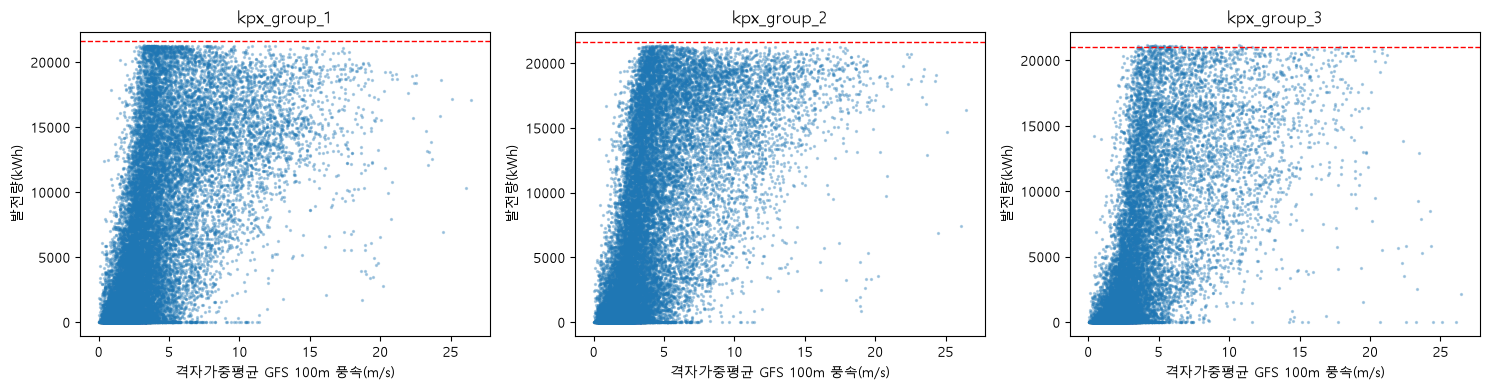

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, group in zip(axes, TARGET_COLS):
    ax.scatter(group_ws100[group], train_base_wide[group], s=2, alpha=0.3)
    ax.axhline(CAPACITY_KWH[group], color="red", linestyle="--", linewidth=1)
    ax.set_title(group)
    ax.set_xlabel("격자가중평균 GFS 100m 풍속(m/s)")
    ax.set_ylabel("발전량(kWh)")
plt.tight_layout()
plt.show()

### 3-2. 풍향별 평균 발전량
산악 지형에서는 풍향에 따라 지형 가속(계곡·능선 효과)이나 터빈 후류 차폐(wake)가 달라져, 같은 풍속이라도 풍향에 따라 발전량이 다를 수 있습니다. 16방위로 나눠 평균 발전량을 봅니다.

In [70]:
COMPASS_16 = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
              "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]

for group in TARGET_COLS:
    u, v = group_weighted_uv(train_base_wide, group, "gfs", "heightAboveGround_100_100u", "heightAboveGround_100_100v")
    wd = wind_direction(u, v)
    wd_bin = (np.floor((wd + 11.25) / 22.5) % 16).astype(int)

    tmp = pd.DataFrame({"wd_bin": wd_bin, "gen": train_base_wide[group]})
    result = tmp.groupby("wd_bin")["gen"].mean()
    result.index = [COMPASS_16[i] for i in result.index]

    print(f"--- {group}: 풍향별 평균 발전량(kWh) ---")
    print(result)

--- kpx_group_1: 풍향별 평균 발전량(kWh) ---
N       1563.406743
NNE     2266.906546
NE      2655.589594
ENE     1392.669739
E        962.621093
ESE     1149.762619
SE      1182.498645
SSE     1433.040966
S       2180.642559
SSW     4542.267095
SW      6807.546245
WSW    10997.492452
W       9481.698520
WNW     3561.945180
NW      2036.426665
NNW     1457.554367
Name: gen, dtype: float64
--- kpx_group_2: 풍향별 평균 발전량(kWh) ---
N       1654.342739
NNE     2639.984608
NE      3306.406882
ENE     1687.945052
E        966.136039
ESE     1019.570827
SE      1009.625398
SSE     1430.780204
S       2303.545574
SSW     5275.408028
SW      8441.978566
WSW    11601.641064
W       9918.657874
WNW     3157.693044
NW      1820.953689
NNW     1371.297023
Name: gen, dtype: float64
--- kpx_group_3: 풍향별 평균 발전량(kWh) ---
N      1007.924087
NNE    1779.034161
NE     2181.509122
ENE    1042.002938
E       551.343594
ESE     619.190299
SE      501.791216
SSE     669.194124
S      1403.814388
SSW    3974.986481
SW     

### 3-3. 높이별 풍속과 발전량의 상관관계
GFS 10m/80m/100m와 LDAPS 10m 중 어느 높이의 풍속이 발전량과 가장 상관이 높은지 비교합니다. 허브 높이에 가까운 GFS 100m가 가장 높을 것으로 예상합니다 (지상 마찰의 영향을 덜 받으므로).

In [71]:
height_configs = {
    "gfs_10m": ("gfs", "heightAboveGround_10_10u", "heightAboveGround_10_10v"),
    "gfs_80m": ("gfs", "heightAboveGround_80_u", "heightAboveGround_80_v"),
    "gfs_100m": ("gfs", "heightAboveGround_100_100u", "heightAboveGround_100_100v"),
    "ldaps_10m": ("ldaps", "heightAboveGround_10_10u", "heightAboveGround_10_10v"),
}

corr_rows = []
for group in TARGET_COLS:
    row = {"group": group}
    for name, (source, u_var, v_var) in height_configs.items():
        u, v = group_weighted_uv(train_base_wide, group, source, u_var, v_var)
        ws = wind_speed(u, v)
        row[name] = train_base_wide[group].corr(ws)
    corr_rows.append(row)

pd.DataFrame(corr_rows).set_index("group")

,gfs_10m,gfs_80m,gfs_100m,ldaps_10m
group,,,,
kpx_group_1,0.619396,0.614955,0.617837,0.668393
kpx_group_2,0.625722,0.624759,0.628410,0.746520
kpx_group_3,0.623837,0.621985,0.625078,0.774813


### 3-4. 계절(공기밀도 대리) × 풍속 구간별 평균 발전량
발전량 공식 P = ½·ρ·A·Cp·v³에서 공기밀도(ρ)는 겨울에 더 높습니다(저온·고압일수록 밀도 상승). 같은 풍속 구간에서 겨울 발전량이 여름보다 높게 나오면, 공기밀도 보정 피처(기온·기압 기반)가 유효하다는 근거가 됩니다.

In [72]:
season_map = {12: "겨울", 1: "겨울", 2: "겨울", 3: "봄", 4: "봄", 5: "봄",
              6: "여름", 7: "여름", 8: "여름", 9: "가을", 10: "가을", 11: "가을"}
season = train_base_wide["forecast_kst_dtm"].dt.month.map(season_map)
ws_bins = [0, 4, 6, 8, 10, 12, 15, 20, 30]

for group in TARGET_COLS:
    ws_bin = pd.cut(group_ws100[group], bins=ws_bins)
    tmp = pd.DataFrame({"ws_bin": ws_bin, "season": season, "gen": train_base_wide[group]})
    pivot = tmp.groupby(["ws_bin", "season"], observed=True)["gen"].mean().unstack()
    print(f"--- {group}: 풍속 구간 × 계절 평균 발전량(kWh) ---")
    print(pivot)

--- kpx_group_1: 풍속 구간 × 계절 평균 발전량(kWh) ---
season              가을            겨울             봄            여름
ws_bin                                                          
(0, 4]     3293.388252   5723.672096   4018.569728   2896.578799
(4, 6]    10052.367087  12955.584998   9484.989847   8132.928737
(6, 8]    13498.915144  14033.718981  11328.262733  10413.142707
(8, 10]   15244.596337  14339.012474  12361.845290  12832.586256
(10, 12]  15680.129316  14611.368967  13420.175561  13950.361464
(12, 15]  16739.383457  15270.357075  15064.825269  15604.870833
(15, 20]  17694.779933  13639.321390  15046.765824  14118.841387
(20, 30]  14805.706368   2820.316000  16470.322889  12722.757667
--- kpx_group_2: 풍속 구간 × 계절 평균 발전량(kWh) ---
season              가을            겨울             봄            여름
ws_bin                                                          
(0, 4]     3359.194480   5866.875550   4320.062147   3189.178934
(4, 6]    10970.901341  13933.162985  10343.607320   9602.286132
(6

## 4. SCADA(터빈 실측) 뜯어보기
SCADA는 train 기간에만 있고 test에는 없어서 **추론 피처로 직접 쓸 수 없습니다** (`leakage-guard` 규칙). 대신 (1) 예보가 실제로 얼마나 틀리는지(NWP 편향), (2) 실제 파워커브 모양, (3) 정지·제한발전 같은 이상 패턴, (4) 그룹-터빈 매핑이 맞는지를 확인하는 **분석 목적**으로만 씁니다.

In [73]:
scada_vestas = pd.read_csv(TRAIN_DIR / "scada_vestas_train.csv", encoding="utf-8-sig")
scada_vestas["kst_dtm"] = pd.to_datetime(scada_vestas["kst_dtm"])

scada_unison = pd.read_csv(TRAIN_DIR / "scada_unison_train.csv", encoding="utf-8-sig")
scada_unison["kst_dtm"] = pd.to_datetime(scada_unison["kst_dtm"])

print("scada_vestas:", scada_vestas.shape)
print("scada_unison:", scada_unison.shape)

scada_vestas: (157819, 37)
scada_unison: (105264, 16)


### 4-0. `power_kw10m`의 실제 단위 확인, 그리고 VESTAS 센서 오류 정리
`data_description.md`는 `power_kw10m`을 "10분 단위 power 값"이라고만 설명합니다. 그런데 VESTAS 12기 전부의 최댓값이 정확히 602로 똑같이 막혀 있다는 게 이상해요 — 설비용량 3.6MW(=3600kW)에 10분(=1/6시간)을 곱한 값이 정확히 600kWh입니다. 이건 "출력(순간 kW)"이 아니라 **"그 10분 동안 만든 에너지(kWh)"라서 생기는 물리적 상한**이라는 뜻이에요. 실제로 `train_labels.csv`와 대조해보면(같은 시각, 같은 그룹 합계) 이 값을 **그대로 6개 더한 값**이 라벨과 거의 일치하고(비율 약 0.98~1.0), 반대로 "출력으로 보고 10/60을 곱한" 값은 라벨보다 약 6배 작습니다. 그래서 이 노트북은 `power_kw10m`을 **10분 에너지(kWh)**로 다룹니다.

또한 VESTAS 12기 전부에서 물리적으로 불가능한 극단값(수천만 단위, 설비용량의 수천 배)이 터빈당 수십~백여 개씩 섞여 있습니다. 대부분(약 94%) 한 시점에 터빈 하나만 튀는 걸로 봐서 개별 통신·센서 순간 오류로 보입니다. 행 전체를 지우면 같은 시각 다른 터빈의 멀쩡한 값까지 버리게 되므로, **그 셀 하나만 결측(NaN) 처리**합니다(전체 행 삭제가 아님).

In [74]:
def clean_extreme_sensor_errors(df, power_cols, capacity_kw, factor=1.5):
    """설비용량의 factor배를 넘는 값은 물리적으로 불가능하므로 그 셀만 NaN 처리한다."""
    cleaned = df.copy()
    threshold = capacity_kw * factor
    error_counts = {}
    for col in power_cols:
        bad = cleaned[col].abs() > threshold
        error_counts[col] = int(bad.sum())
        cleaned.loc[bad, col] = np.nan
    return cleaned, error_counts


VESTAS_CAPACITY_KW = 3600  # info.xlsx capacity_mw(3.6MW) 기준

vestas_power_cols_all = [c for c in scada_vestas.columns if c.endswith("_power_kw10m")]
scada_vestas, vestas_error_counts = clean_extreme_sensor_errors(
    scada_vestas, vestas_power_cols_all, VESTAS_CAPACITY_KW
)

total_errors = sum(vestas_error_counts.values())
print(f"VESTAS 전체 이상치(센서 오류) 셀 수: {total_errors} / {scada_vestas.shape[0] * len(vestas_power_cols_all)}")
for col, n in vestas_error_counts.items():
    print(f"  {col}: {n}개 -> NaN 처리")

VESTAS 전체 이상치(센서 오류) 셀 수: 868 / 1893828
  vestas_wtg01_power_kw10m: 74개 -> NaN 처리
  vestas_wtg02_power_kw10m: 70개 -> NaN 처리
  vestas_wtg03_power_kw10m: 88개 -> NaN 처리
  vestas_wtg04_power_kw10m: 44개 -> NaN 처리
  vestas_wtg05_power_kw10m: 72개 -> NaN 처리
  vestas_wtg06_power_kw10m: 60개 -> NaN 처리
  vestas_wtg07_power_kw10m: 68개 -> NaN 처리
  vestas_wtg08_power_kw10m: 102개 -> NaN 처리
  vestas_wtg09_power_kw10m: 52개 -> NaN 처리
  vestas_wtg10_power_kw10m: 68개 -> NaN 처리
  vestas_wtg11_power_kw10m: 98개 -> NaN 처리
  vestas_wtg12_power_kw10m: 72개 -> NaN 처리


**이 극단값들이 왜 생겼는지 조금 더 파봅니다.** 아래 셀은 방금 NaN 처리하기 *전의* 원본 값 기준으로, 극단값이 나온 순간의 풍속이 0인지, 그 직전에 "풍속=0 & 파워=0"이 얼마나 오래 이어졌는지를 확인합니다. 이걸 보는 이유: 큰 음수 다음에 큰 양수가 따라오는 패턴이 있다면(반대 부호로 서로 상쇄되는 크기), 이건 무작위 노이즈가 아니라 **누적 계량기(count가 쌓이는 방식의 센서)가 한동안 잘못된 값에 멈춰 있다가 복구되는 순간, 그 사이에 밀린 차이가 한꺼번에 튀어나오는 현상**일 가능성이 높습니다.

In [75]:
scada_vestas_raw = pd.read_csv(TRAIN_DIR / "scada_vestas_train.csv", encoding="utf-8-sig")
scada_vestas_raw["kst_dtm"] = pd.to_datetime(scada_vestas_raw["kst_dtm"])
scada_vestas_raw = scada_vestas_raw.sort_values("kst_dtm").reset_index(drop=True)

col, ws_col = "vestas_wtg01_power_kw10m", "vestas_wtg01_ws"
bad_idx = scada_vestas_raw.index[scada_vestas_raw[col].abs() > 10000]


def zero_streak_before(df, i, power_col, ws_col):
    j, n = i - 1, 0
    while j >= 0 and df.loc[j, power_col] == 0 and df.loc[j, ws_col] == 0:
        n += 1
        j -= 1
    return n


ws_at_spike = scada_vestas_raw.loc[bad_idx, ws_col]
streaks = [zero_streak_before(scada_vestas_raw, i, col, ws_col) for i in bad_idx]

print("wtg01 이상치 개수:", len(bad_idx))
print(f"스파이크 순간 풍속이 정확히 0인 비율: {(ws_at_spike == 0).mean():.1%}")
print("스파이크 직전 (풍속=0 & 파워=0) 연속 구간 길이(10분 단위) 분포:")
print(pd.Series(streaks).describe())

wtg01 이상치 개수: 74
스파이크 순간 풍속이 정확히 0인 비율: 50.0%
스파이크 직전 (풍속=0 & 파워=0) 연속 구간 길이(10분 단위) 분포:
count     74.000000
mean      15.635135
std       68.473087
min        0.000000
25%        0.000000
50%        0.000000
75%        3.000000
max      493.000000
dtype: float64


**해석**: 두 가지 다른 패턴이 섞여 있습니다.
1. 대부분은 그 순간 값 하나만 단독으로 튀는 경우입니다 — 누적 계량기 값을 순간적으로 잘못 읽은 단발성 오류로, 어딘가에서(꼭 바로 다음 10분이 아닐 수도 있음) 비슷한 크기의 반대 부호 값으로 상쇄됩니다.
2. 소수는 "풍속=0 & 파워=0"이 몇 시간~며칠씩 이어지다가, 복구 시점에 큰 값이 튀어나오는 경우입니다 — 터빈이 통째로 오프라인/통신두절 상태였고, 그동안 밀린 값이 한꺼번에 반영된 것으로 보입니다.

두 경우 모두 "그 순간의 값은 믿을 수 없다"는 결론은 같습니다. 다만 2번 유형에서는 스파이크 앞뒤의 "0" 구간도 실제로는 얼마나 발전했는지 알 수 없는 구간이라는 점은 참고만 해둡니다 (SCADA는 어차피 분석·검증 목적으로만 쓰고 추론 피처로는 안 쓰므로, 지금 단계에서 이 구간을 더 정교하게 복원할 필요는 없습니다 — 4-4번 검증에서 그룹 상관관계가 0.9998로 이미 충분히 높게 나왔습니다).

### 4-1. 예보 풍속 vs SCADA 실측 풍속 (NWP 편향)
SCADA는 10분 단위라서, 라벨과 같은 방식(구간 종료 시각 기준)으로 1시간 단위로 평균 내 정렬한 뒤, 예보 풍속(3절의 격자가중평균 GFS 100m)과 비교합니다. 편향(bias)과 RMSE는 "예보가 원래 이만큼은 틀린다"는 이 문제의 오차 하한선을 알려줍니다.

In [76]:
group1_ws_cols = [f"vestas_wtg{i:02d}_ws" for i in range(1, 7)]
group2_ws_cols = [f"vestas_wtg{i:02d}_ws" for i in range(7, 13)]
unison_ws_cols = [c for c in scada_unison.columns if c.endswith("_ws")]

scada_vestas_hourly_ws = (
    scada_vestas.set_index("kst_dtm")[group1_ws_cols + group2_ws_cols]
    .resample("h", label="right", closed="right")
    .mean()
)
scada_unison_hourly_ws = (
    scada_unison.set_index("kst_dtm")[unison_ws_cols]
    .resample("h", label="right", closed="right")
    .mean()
)

scada_ws_by_group = {
    "kpx_group_1": scada_vestas_hourly_ws[group1_ws_cols].mean(axis=1),
    "kpx_group_2": scada_vestas_hourly_ws[group2_ws_cols].mean(axis=1),
    "kpx_group_3": scada_unison_hourly_ws.mean(axis=1),
}

for group in TARGET_COLS:
    print(f"{group} SCADA 시간평균 풍속 요약:")
    print(scada_ws_by_group[group].describe())

kpx_group_1 SCADA 시간평균 풍속 요약:
count    26304.000000
mean         6.782880
std          3.365441
min          0.000000
25%          4.147361
50%          6.326667
75%          9.080556
max         22.431528
dtype: float64
kpx_group_2 SCADA 시간평균 풍속 요약:
count    26304.000000
mean         7.203019
std          3.855660
min          0.000000
25%          4.170236
50%          6.440292
75%          9.786111
max         25.201333
dtype: float64
kpx_group_3 SCADA 시간평균 풍속 요약:
count    17536.000000
mean         5.848059
std          3.605820
min          0.570333
25%          2.828167
50%          5.015000
75%          8.075417
max         23.766000
dtype: float64


In [77]:
forecast_ws_indexed = {
    group: group_ws100[group].set_axis(train_base_wide["forecast_kst_dtm"])
    for group in TARGET_COLS
}

for group in TARGET_COLS:
    compare = pd.DataFrame({
        "forecast_ws": forecast_ws_indexed[group],
        "scada_ws": scada_ws_by_group[group],
    }).dropna()
    diff = compare["scada_ws"] - compare["forecast_ws"]
    corr = compare["forecast_ws"].corr(compare["scada_ws"])
    print(f"--- {group} ---")
    print(f"비교 가능 시간 수: {len(compare)}, 상관: {corr:.3f}, "
          f"편향(실측-예보) 평균: {diff.mean():.3f} m/s, RMSE: {np.sqrt((diff ** 2).mean()):.3f} m/s")

--- kpx_group_1 ---
비교 가능 시간 수: 26304, 상관: 0.701, 편향(실측-예보) 평균: 2.816 m/s, RMSE: 3.788 m/s
--- kpx_group_2 ---
비교 가능 시간 수: 26304, 상관: 0.698, 편향(실측-예보) 평균: 3.236 m/s, RMSE: 4.281 m/s
--- kpx_group_3 ---
비교 가능 시간 수: 17536, 상관: 0.713, 편향(실측-예보) 평균: 1.952 m/s, RMSE: 3.244 m/s


### 4-2. SCADA 파워커브
대표로 VESTAS 1호기, UNISON 1호기의 (풍속, 10분 에너지) 산점도를 봅니다. 이 커브 모양이 3-1에서 본 (예보풍속, 발전량) 산점도보다 훨씬 선명할 것으로 예상합니다 — 예보 풍속에는 예보 오차가 섞여 있지만, SCADA는 터빈이 실제로 겪은 바람이기 때문입니다. (VESTAS는 4-0에서 이미 센서 오류를 NaN 처리했으니, 정상 범위만 보이는 깨끗한 커브가 나와야 합니다.)

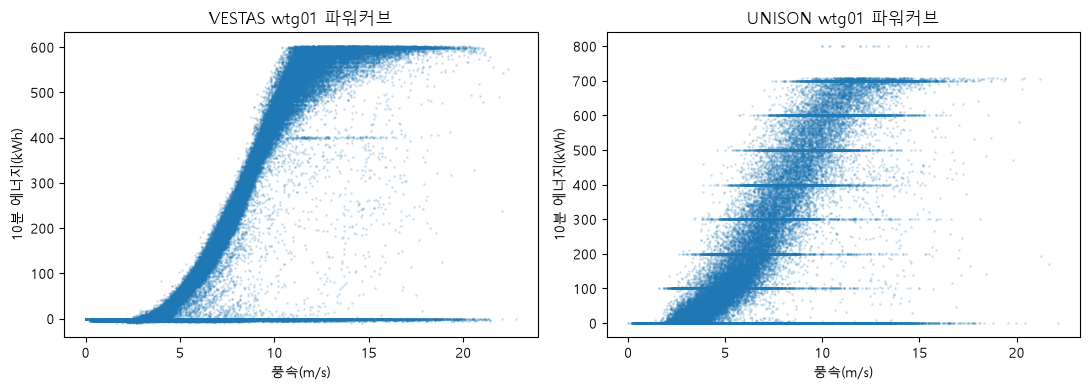

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(scada_vestas["vestas_wtg01_ws"], scada_vestas["vestas_wtg01_power_kw10m"], s=1, alpha=0.15)
axes[0].set_title("VESTAS wtg01 파워커브")
axes[0].set_xlabel("풍속(m/s)")
axes[0].set_ylabel("10분 에너지(kWh)")

axes[1].scatter(scada_unison["unison_wtg01_ws"], scada_unison["unison_wtg01_power_kw10m"], s=1, alpha=0.15)
axes[1].set_title("UNISON wtg01 파워커브")
axes[1].set_xlabel("풍속(m/s)")
axes[1].set_ylabel("10분 에너지(kWh)")
plt.tight_layout()
plt.show()

wtg01 하나만 보면 이 터빈만의 특이한 현상인지, 12대(VESTAS)·5대(UNISON) 전체에 공통인 현상인지 알 수 없습니다. 터빈 전체를 한 번에 그려서 비교합니다.

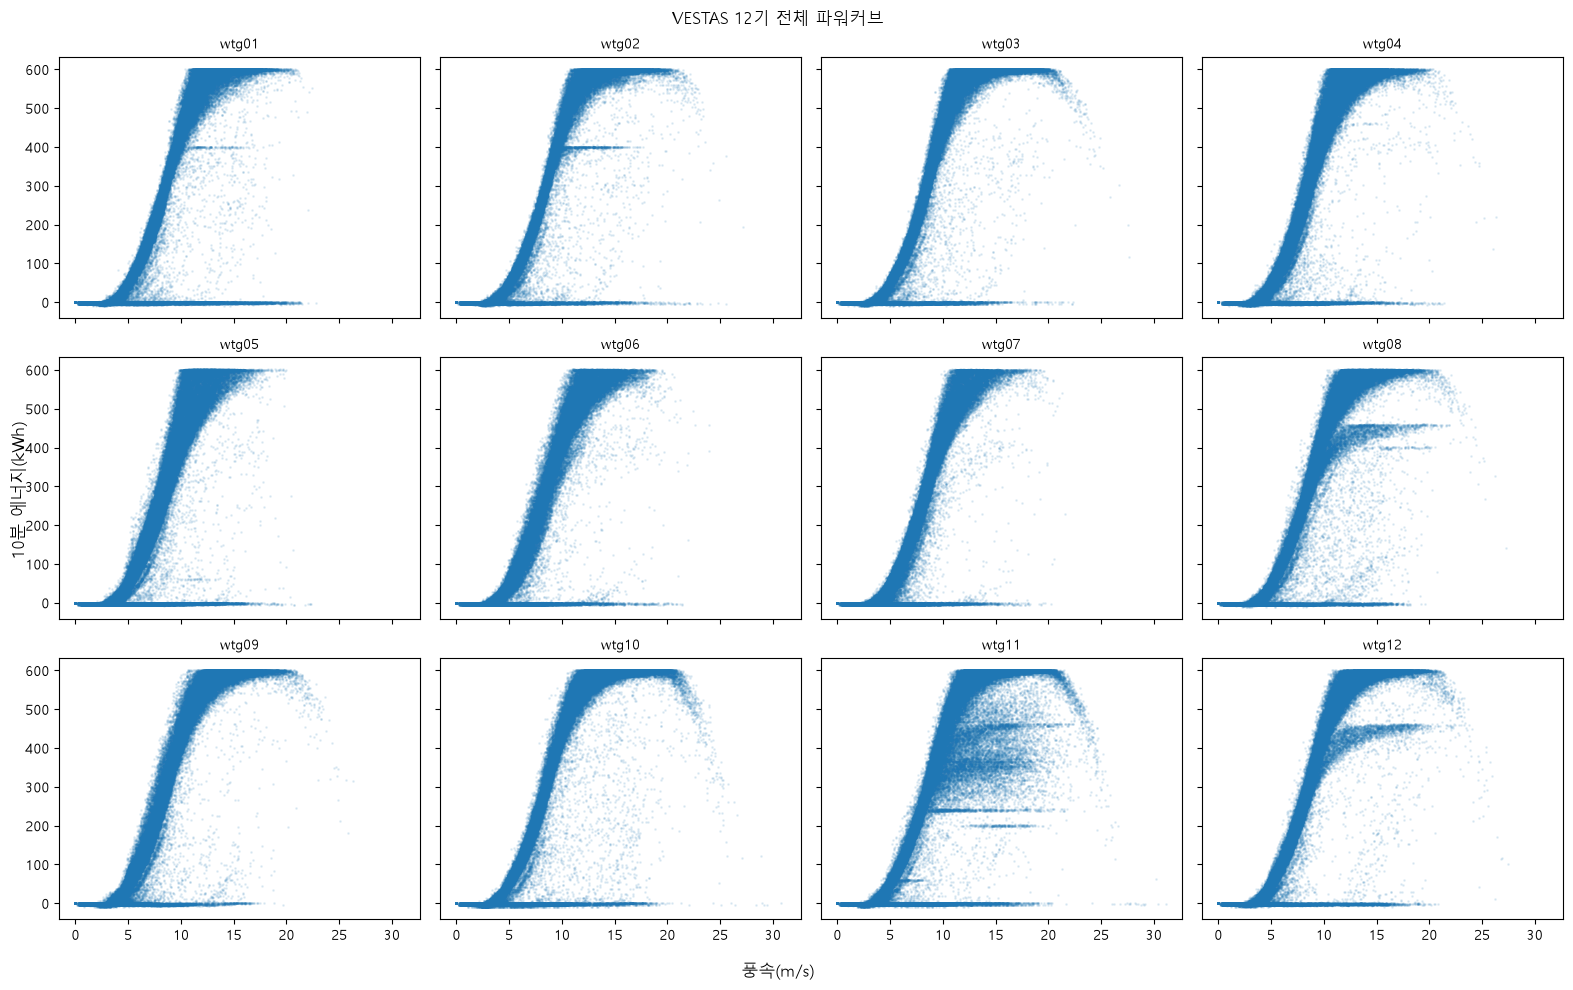

In [79]:
vestas_wtg_ids = [f"{i:02d}" for i in range(1, 13)]

fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
for ax, wtg_id in zip(axes.flat, vestas_wtg_ids):
    ws_col = f"vestas_wtg{wtg_id}_ws"
    power_col = f"vestas_wtg{wtg_id}_power_kw10m"
    ax.scatter(scada_vestas[ws_col], scada_vestas[power_col], s=1, alpha=0.1)
    ax.set_title(f"wtg{wtg_id}", fontsize=10)

fig.supxlabel("풍속(m/s)")
fig.supylabel("10분 에너지(kWh)")
fig.suptitle("VESTAS 12기 전체 파워커브")
plt.tight_layout()
plt.show()

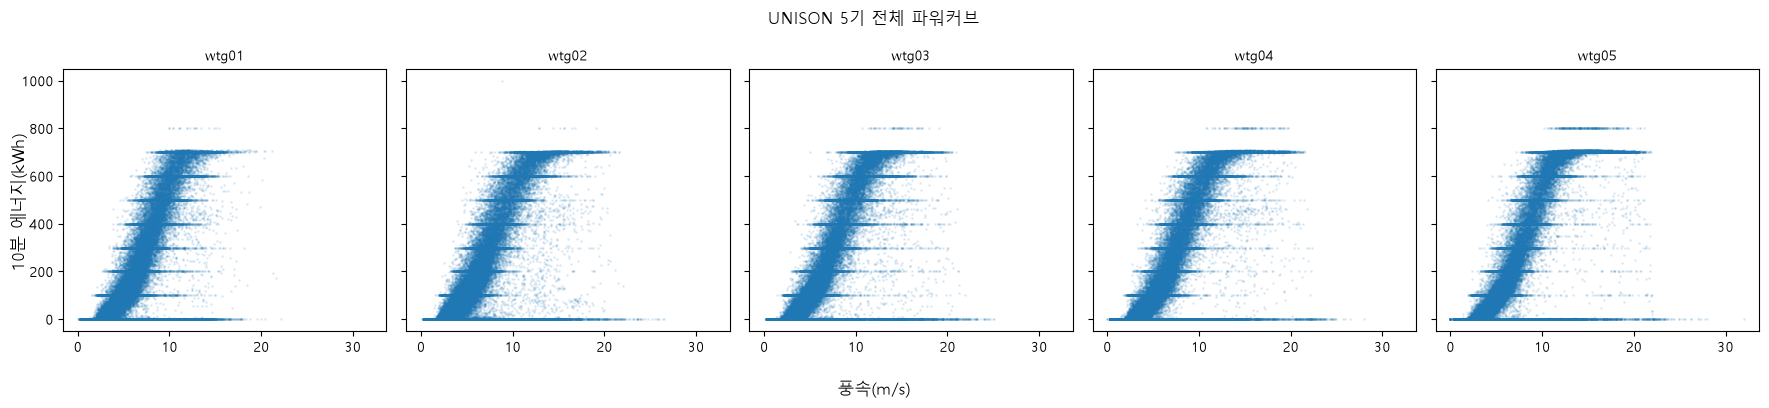

In [80]:
unison_wtg_ids = [f"{i:02d}" for i in range(1, 6)]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharex=True, sharey=True)
for ax, wtg_id in zip(axes, unison_wtg_ids):
    ws_col = f"unison_wtg{wtg_id}_ws"
    power_col = f"unison_wtg{wtg_id}_power_kw10m"
    ax.scatter(scada_unison[ws_col], scada_unison[power_col], s=1, alpha=0.1)
    ax.set_title(f"wtg{wtg_id}", fontsize=10)

fig.supxlabel("풍속(m/s)")
fig.supylabel("10분 에너지(kWh)")
fig.suptitle("UNISON 5기 전체 파워커브")
plt.tight_layout()
plt.show()

**VESTAS wtg01의 400 부근 뭉침과 UNISON의 100단위 계단은 서로 다른 현상입니다.** 값 하나가 이웃 값들보다 비정상적으로 많이 나오는지(=인위적인 계단), 아니면 그냥 그 근처 값들이 골고루 많은지(=자연스러운 밀집)를 숫자로 구분해봅니다: 어떤 값의 빈도를 그 앞뒤 ±5 이웃 값의 평균 빈도로 나눈 비율이 크면(예: 수십~수백 배) 인위적 계단이고, 1 근처면 자연스러운 밀집입니다.

In [81]:
def spike_ratio(series, center, window=5):
    """center 값의 빈도가 그 앞뒤 이웃(±window, center 제외) 평균 빈도의 몇 배인지 계산한다."""
    vc = series.value_counts()
    at_center = vc.get(center, 0)
    neighbors = [vc.get(center + d, 0) for d in range(-window, window + 1) if d != 0]
    avg_neighbor = np.mean(neighbors)
    ratio = at_center / avg_neighbor if avg_neighbor > 0 else np.inf
    return at_center, avg_neighbor, ratio


vestas_wtg01_clean = scada_vestas["vestas_wtg01_power_kw10m"]

print("VESTAS wtg01 @400 (뭉쳐 보이는 지점):", spike_ratio(vestas_wtg01_clean, 400))
print("VESTAS wtg01 @600 (정격 근처 평평한 구간):", spike_ratio(vestas_wtg01_clean, 600))
print("UNISON wtg01 @400 (계단으로 의심되는 지점):", spike_ratio(scada_unison["unison_wtg01_power_kw10m"], 400))

VESTAS wtg01 @400 (뭉쳐 보이는 지점): (np.int64(87), np.float64(129.0), np.float64(0.6744186046511628))
VESTAS wtg01 @600 (정격 근처 평평한 구간): (np.int64(1248), np.float64(745.3), np.float64(1.6744934925533344))
UNISON wtg01 @400 (계단으로 의심되는 지점): (np.int64(2943), np.float64(26.8), np.float64(109.81343283582089))


**결과 해석**: VESTAS @400의 비율은 1 미만(오히려 이웃보다 적음) — 그냥 파워커브가 풍속에 따라 완만히 증가하는 구간이라 자연스럽게 값이 몰려 보이는 것뿐입니다. VESTAS @600은 비율이 약간 높은 정도(1~2배) — 정격 출력 근처에서 커브가 평평해지는(rated plateau) **정상적인 물리 현상**입니다. 반면 UNISON @400은 비율이 100배 이상 — 이웃 값보다 압도적으로 많이 나오는 것은 자연스러운 밀도로는 설명이 안 되고, 컨트롤러가 그 값에 출력을 붙들어 두는 **인위적인 계단(출력제한)**이라는 결론을 뒷받침합니다.

**UNISON 그래프에서 0, 100, 200 ... 처럼 100 단위로 가로줄이 두드러지게 보인다면 그건 오류가 아닙니다.** 아래 셀로 실제로 특정 값에 점이 몰려 있는지 확인합니다 — 이웃 값(예: 99, 101)보다 딱 떨어지는 값(예: 100)에서 빈도가 수십~수백 배 높으면, 터빈 컨트롤러가 출력을 특정 단계값에 붙들어 두는 **출력제한(curtailment) 운영**의 흔적입니다.

설비용량 기준 10분 상한(4.2MW×10/60=700kWh)을 넘는 값(701~1000)도 관측되는데, 대부분(701~710)은 700 근처의 자연스러운 측정 변동이라 문제없습니다. 다만 **정확히 800에서도 700과 똑같은 패턴(이웃 값엔 없는데 800에만 점이 몰림)이 나타나는지**는 아래에서 직접 확인합니다 — 그렇다면 출력제한 계단이 700에서 끝나는 게 아니라 800(드물게 900·1000)까지 이어지는 더 넓은 사다리라는 뜻이고, "설비가 못 내는 값이 튀어나온 오류"가 아니라 "정책상 더 높은 단계도 가끔 허용한다"는 같은 결론(출력제한)을 재확인하는 것뿐입니다.

In [82]:
unison_power_cols_all = [c for c in scada_unison.columns if c.endswith("_power_kw10m")]

for col in unison_power_cols_all:
    print(f"{col}: 최댓값={scada_unison[col].max()}")

vc = scada_unison["unison_wtg01_power_kw10m"].value_counts()
print()
print("unison_wtg01: 100의 배수 값과 그 이웃 값의 빈도 비교")
for center in [100, 200, 300, 400, 500, 600, 700, 800]:
    neighbors = {v: int(vc.get(v, 0)) for v in [center - 1, center, center + 1]}
    print(f"  {center}: {neighbors}")

print()
print("터빈별 700 vs 800에서의 빈도 (둘 다 비슷하게 튀면 같은 종류의 계단):")
for col in unison_power_cols_all:
    vc_col = scada_unison[col].value_counts()
    print(f"  {col}: @700={int(vc_col.get(700.0, 0))}, @800={int(vc_col.get(800.0, 0))}")

unison_wtg01_power_kw10m: 최댓값=800.0
unison_wtg02_power_kw10m: 최댓값=1000.0
unison_wtg03_power_kw10m: 최댓값=900.0
unison_wtg04_power_kw10m: 최댓값=800.0
unison_wtg05_power_kw10m: 최댓값=800.0

unison_wtg01: 100의 배수 값과 그 이웃 값의 빈도 비교
  100: {99: 82, 100: 9153, 101: 86}
  200: {199: 47, 200: 4937, 201: 49}
  300: {299: 37, 300: 3310, 301: 39}
  400: {399: 33, 400: 2943, 401: 22}
  500: {499: 22, 500: 2746, 501: 23}
  600: {599: 21, 600: 3243, 601: 32}
  700: {699: 45, 700: 2771, 701: 43}
  800: {799: 0, 800: 19, 801: 0}

터빈별 700 vs 800에서의 빈도 (둘 다 비슷하게 튀면 같은 종류의 계단):
  unison_wtg01_power_kw10m: @700=2771, @800=19
  unison_wtg02_power_kw10m: @700=2506, @800=9
  unison_wtg03_power_kw10m: @700=6225, @800=59
  unison_wtg04_power_kw10m: @700=5762, @800=99
  unison_wtg05_power_kw10m: @700=9798, @800=294


### 4-3. 이상 패턴: 바람은 부는데 발전이 0인 경우, 음수 발전
풍속이 cut-in(약 3~4 m/s)을 넘었는데 출력이 0 이하라면 정지·제한발전(curtailment) 상태를 의심할 수 있습니다. 이런 행은 지우지 않고 존재만 확인합니다 (지울지 말지는 검증 점수로 나중에 결정 — `preprocessing` 스킬 규칙). VESTAS는 4-0에서 이미 센서 오류를 NaN 처리했으므로, 여기서 보이는 음수는 진짜 작은 음수(대기 중 자체 소비 전력 등)만 남아 있어야 합니다.

In [83]:
checks = [
    ("vestas_wtg01", scada_vestas, "vestas_wtg01_ws", "vestas_wtg01_power_kw10m"),
    ("unison_wtg01", scada_unison, "unison_wtg01_ws", "unison_wtg01_power_kw10m"),
]

for name, df_src, ws_col, power_col in checks:
    suspect = df_src[(df_src[ws_col] > 4) & (df_src[power_col] <= 0)]
    negative = df_src[df_src[power_col] < 0]
    print(f"{name}: 전체 {len(df_src)}행 중 풍속>4인데 power<=0 = {len(suspect)}건, 음수 power = {len(negative)}건")

vestas_wtg01: 전체 157819행 중 풍속>4인데 power<=0 = 9238건, 음수 power = 24747건
unison_wtg01: 전체 105264행 중 풍속>4인데 power<=0 = 9531건, 음수 power = 0건


### 4-4. SCADA 합계 vs train_labels 대조 (그룹-터빈 매핑 최종 검증)
4-0에서 확인했듯 `power_kw10m`은 이미 **10분간 에너지(kWh)**이므로, 한 시간에 여섯 번 걷힌 값을 그대로 더하면 그 시간의 발전량(kWh)이 됩니다(추가로 시간 비율을 곱할 필요가 없습니다). 이렇게 계산한 그룹별 합계가 `train_labels.csv`와 비슷하게 움직이면, 2절에서 만든 그룹-터빈 매핑이 실제 발전량 기준으로도 맞다는 뜻입니다. VESTAS는 4-0에서 이상치를 NaN 처리해뒀으므로, 그 값들은 이 합계에서 자동으로 빠집니다(`sum`은 NaN을 0으로 취급하며 건너뜁니다 — 극단값이 섞여 합계를 오염시키는 것보다는, 그 10분 구간을 모르는 값으로 두는 편이 안전합니다).

In [84]:
def to_hourly_kwh(df, power_cols):
    return (
        df.set_index("kst_dtm")[power_cols]
        .resample("h", label="right", closed="right")
        .sum()
    )


group1_power_cols = [f"vestas_wtg{i:02d}_power_kw10m" for i in range(1, 7)]
group2_power_cols = [f"vestas_wtg{i:02d}_power_kw10m" for i in range(7, 13)]
unison_power_cols = [c for c in scada_unison.columns if c.endswith("_power_kw10m")]

vestas_hourly_kwh = to_hourly_kwh(scada_vestas, group1_power_cols + group2_power_cols)
unison_hourly_kwh = to_hourly_kwh(scada_unison, unison_power_cols)

scada_kwh_by_group = {
    "kpx_group_1": vestas_hourly_kwh[group1_power_cols].sum(axis=1),
    "kpx_group_2": vestas_hourly_kwh[group2_power_cols].sum(axis=1),
    "kpx_group_3": unison_hourly_kwh.sum(axis=1),
}

labels_indexed = labels_df.set_index("forecast_kst_dtm")

for group in TARGET_COLS:
    compare = pd.DataFrame({
        "label": labels_indexed[group],
        "scada_sum": scada_kwh_by_group[group],
    }).dropna()
    corr = compare["label"].corr(compare["scada_sum"])
    print(f"{group}: 비교 가능 시간 {len(compare)}개, 라벨-SCADA합 상관 = {corr:.4f}")

kpx_group_1: 비교 가능 시간 26200개, 라벨-SCADA합 상관 = 0.9998
kpx_group_2: 비교 가능 시간 26201개, 라벨-SCADA합 상관 = 0.9998
kpx_group_3: 비교 가능 시간 17538개, 라벨-SCADA합 상관 = 0.9966


## 5. 시간 무결성 확인
시각 데이터를 다루는 마지막 기본 점검입니다: 중복된 시각이 없는지, 시간 간격이 항상 1시간인지, train 마지막 시각과 test 첫 시각이 정확히 이어지는지 확인합니다.

In [85]:
print("중복 시각 개수:", train_base_wide["forecast_kst_dtm"].duplicated().sum())

diffs = train_base_wide["forecast_kst_dtm"].diff().dropna()
print("시간 간격 고유값:", diffs.unique())

중복 시각 개수: 0
시간 간격 고유값: <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[us]


In [86]:
train_last = train_base_wide["forecast_kst_dtm"].max()
test_first = test_base_wide["forecast_kst_dtm"].min()

print("train 마지막 시각:", train_last)
print("test 첫 시각:", test_first)
print("정확히 1시간 차이인가:", (test_first - train_last) == pd.Timedelta(hours=1))

train 마지막 시각: 2025-01-01 00:00:00
test 첫 시각: 2025-01-01 01:00:00
정확히 1시간 차이인가: True


## 요약 — 이 노트북에서 확인해야 할 것 / 다음 단계로 넘기는 것

**민석님께 요청**: 위 셀들을 실행한 뒤, 특히 아래 항목의 실제 출력 결과를 알려주세요. 그 결과를 보고 `reports/02_eda.md`(Why/How/Result/So-what)를 정확하게 작성하겠습니다.

1. 1-1번 셀: 라벨 결측이 특정 월에 몰려 있는지
2. 2-2/2-4번 셀: test LDAPS 752개 결측의 정확한 시각과, 발표분 전체 누락인지 여부
3. 2-3번 셀: `data_available_kst_dtm` 규칙이 실제로 지켜지는지 (시간 차이 분포)
4. 3-1, 3-3번 셀: 파워커브 모양과 높이별 상관 순위 (어느 높이가 발전량과 가장 관련 있는지)
5. 4-1, 4-4번 셀: NWP 편향/RMSE 수치와 그룹-터빈 매핑 상관계수 (매핑이 맞는지 최종 확인)

**다음 노트북(`03_features.ipynb`)으로 넘어갈 후보**
- GFS 100m(허브 높이 근접) 풍속·풍향 sin/cos, u/v 3제곱
- 공기밀도 보정 피처(기온·기압 기반)
- 격자 표준편차(예보 불확실성 대리) 및 GFS-LDAPS 차이(다중 NWP 불일치 피처)
- 계절·시간대 주기 피처 (월/시 sin·cos)

**이해 체크**: "왜 SCADA 데이터를 피처로 직접 쓰면 안 되는지"를 한 문장으로 말할 수 있으면 이 노트북의 핵심을 이해하신 거예요.